In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [3]:
df= pd.read_csv("matches.csv",index_col=[0])

In [4]:
df

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.0,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.0,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,NaN,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.0,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,NaN,5.0,8.0,Priyansh Arya,Ayush Matre,73.0,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,NaN,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.0,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,NaN,0.0,Ravi Bishnoi,Dhruv Jurel,75.0,Ravi Bishnoi,4--41,No


In [5]:
df.isnull().sum()

date                    0
venue                   0
team1                   0
team2                   0
stage                   0
toss_winner             0
toss_decision           0
first_ings_score        1
first_ings_wkts         1
second_ings_score       1
second_ings_wkts        1
match_result            0
match_winner            1
wb_runs                24
wb_wickets             17
balls_left              1
player_of_the_match     1
top_scorer              1
highscore               1
best_bowling            1
best_bowling_figure     1
super_over_match        0
dtype: int64

### Data  preprocessing

In [6]:
df.dtypes

date                       str
venue                      str
team1                      str
team2                      str
stage                      str
toss_winner                str
toss_decision              str
first_ings_score       float64
first_ings_wkts        float64
second_ings_score      float64
second_ings_wkts       float64
match_result               str
match_winner               str
wb_runs                float64
wb_wickets             float64
balls_left             float64
player_of_the_match        str
top_scorer                 str
highscore              float64
best_bowling               str
best_bowling_figure        str
super_over_match           str
dtype: object

In [7]:
# Inforamtion about data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 1 to 39
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 39 non-null     str    
 1   venue                39 non-null     str    
 2   team1                39 non-null     str    
 3   team2                39 non-null     str    
 4   stage                39 non-null     str    
 5   toss_winner          39 non-null     str    
 6   toss_decision        39 non-null     str    
 7   first_ings_score     38 non-null     float64
 8   first_ings_wkts      38 non-null     float64
 9   second_ings_score    38 non-null     float64
 10  second_ings_wkts     38 non-null     float64
 11  match_result         39 non-null     str    
 12  match_winner         38 non-null     str    
 13  wb_runs              15 non-null     float64
 14  wb_wickets           22 non-null     float64
 15  balls_left           38 non-null     float64
 16  pla

In [8]:
# Describe data set 
df.describe()

,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,wb_runs,wb_wickets,balls_left,highscore
count,38.000000,38.000000,38.000000,38.000000,15.000000,22.000000,38.000000,38.000000
mean,190.526316,6.289474,175.500000,6.052632,41.666667,5.772727,10.684211,79.447368
std,39.394565,2.470451,39.747684,2.670635,30.658643,1.477830,15.773918,24.521031
min,75.000000,2.000000,77.000000,1.000000,1.000000,3.000000,0.000000,34.000000
25%,159.750000,4.250000,159.250000,4.000000,20.500000,5.000000,0.250000,60.750000
50%,197.000000,6.000000,180.000000,5.000000,40.000000,6.000000,6.000000,77.500000
75%,215.000000,8.000000,203.750000,8.000000,55.500000,6.000000,12.000000,91.750000
max,264.000000,10.000000,265.000000,10.000000,103.000000,9.000000,81.000000,152.000000


In [9]:
# first 7 rows
df.head(14)


,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.0,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.0,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,NaN,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.0,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,NaN,5.0,8.0,Priyansh Arya,Ayush Matre,73.0,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,NaN,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.0,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,NaN,0.0,Ravi Bishnoi,Dhruv Jurel,75.0,Ravi Bishnoi,4--41,No


In [10]:
# last seven rows
df.tail(14)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
26,"April 18, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,DC,League,DC,Bowl,175.0,8.0,179.0,...,DC,NaN,6.0,1.0,Tristan Stubbs,Phil Salt,63.0,Bhuvneshwar Kumar,3--26,No
27,"April 18, 2026","Rajiv Gandhi International Stadium, Hyderabad",SRH,CSK,League,CSK,Bowl,194.0,9.0,184.0,...,SRH,10.0,NaN,0.0,Eshan Malinga,Abhishek Sharma,59.0,Eshan Malinga,3--29,No
28,"April 19, 2026","Eden Gardens, Kolkata",KKR,RR,League,RR,Bat,155.0,9.0,161.0,...,KKR,NaN,4.0,2.0,Varun Chakravarthy,Rinku Singh,53.0,Varun Chakravarthy,3--14,No
29,"April 19, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,LSG,League,LSG,Bowl,254.0,7.0,200.0,...,PBKS,54.0,NaN,0.0,Priyansh Arya,Priyansh Arya,93.0,Prince Yadav,2--25,No
30,"April 20, 2026","Narendra Modi Stadium, Ahmedabad",GT,MI,League,GT,Bowl,199.0,5.0,100.0,...,MI,99.0,NaN,25.0,Tilak Varma,Tilak Varma,101.0,Ashwani Kumar,4--24,No
31,"April 21, 2026","Rajiv Gandhi International Stadium, Hyderabad",SRH,DC,League,DC,Bowl,242.0,2.0,195.0,...,SRH,47.0,NaN,0.0,Abhishek Sharma,Abhishek Sharma,135.0,Eshan Malinga,4--32,No
32,"April 22, 2026","Ekana Cricket Stadium, Lucknow",LSG,RR,League,LSG,Bowl,159.0,6.0,119.0,...,LSG,40.0,NaN,12.0,Ravindra Jadeja,Mitchell Marsh,55.0,Jofra Archer,3--20,No
33,"April 23, 2026","Wankhede Stadium, Mumbai",MI,CSK,League,MI,Bowl,207.0,6.0,104.0,...,CSK,103.0,NaN,6.0,Sanju Samson,Sanju Samson,101.0,Akeal Hosein,4--17,No
34,"April 24, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,GT,League,RCB,Bowl,205.0,3.0,206.0,...,RCB,NaN,5.0,7.0,Virat Kohli,Sai Sudarshan,100.0,Rashid Khan,2--49,No


In [11]:
df.isnull().sum()

date                    0
venue                   0
team1                   0
team2                   0
stage                   0
toss_winner             0
toss_decision           0
first_ings_score        1
first_ings_wkts         1
second_ings_score       1
second_ings_wkts        1
match_result            0
match_winner            1
wb_runs                24
wb_wickets             17
balls_left              1
player_of_the_match     1
top_scorer              1
highscore               1
best_bowling            1
best_bowling_figure     1
super_over_match        0
dtype: int64

In [12]:
df[df.duplicated()]

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,


In [13]:
df["first_ings_score"].unique()


array([201., 220., 127., 162., 141., 226., 209., 210., 156., 250.,  nan,
       150., 181., 219., 212., 164., 240., 216., 192., 146., 195., 180.,
       175., 194., 155., 254., 199., 242., 159., 207., 205., 264., 228.,
       158.,  75.])

In [75]:
df["first_ings_score"].mode()


0    155.0
1    162.0
2    201.0
3    210.0
Name: first_ings_score, dtype: float64

In [76]:
df.fillna({"first_ings_score":df["first_ings_score"].mode()[0]},inplace=True)


,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,NaN,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,NaN,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [77]:
df["first_ings_wkts"].unique()

array([ 9.,  4., 10.,  6.,  8.,  5.,  3., nan,  2.,  7.])

In [99]:
df["first_ings_wkts"].mode()

0    6.0
Name: first_ings_wkts, dtype: float64

In [100]:
df.fillna({"first_ings_wkts":df["first_ings_wkts"].mode()[0]},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,NaN,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,NaN,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [101]:
df["second_ings_score"].unique()


array([203., 224., 128., 165., 145., 161., 210., 164., 204., 160., 207.,
        nan, 123., 209., 182., 202., 223., 189., 222., 159., 149., 198.,
       181., 179., 184., 200., 100., 195., 119., 104., 206., 265., 229.,
       162., 155.,  77.])

In [122]:
df["second_ings_score"].mode()


0    160.0
1    161.0
2    165.0
Name: second_ings_score, dtype: float64

In [123]:
df.fillna({"second_ings_score":df["second_ings_score"].mode()[0]},inplace=True
)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,NaN,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,NaN,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [102]:
df["second_ings_wkts"].unique()


array([ 4.,  2.,  7., 10.,  5.,  8., nan,  9.,  3.,  6.,  1.])

In [153]:
df["second_ings_wkts"].mode()


0    4.0
1    5.0
Name: second_ings_wkts, dtype: float64

In [154]:
df.fillna({"second_ings_wkts":df["second_ings_wkts"].mode()[1]},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [155]:
df["match_winner"].unique()


<ArrowStringArray>
['RCB', 'MI', 'RR', 'PBKS', 'DC', 'SRH', 'LSG', 'noresult', 'GT', 'CSK',
 'KKR']
Length: 11, dtype: str

In [156]:
df["match_winner"].mode()


0    PBKS
1     RCB
Name: match_winner, dtype: str

In [157]:
df.fillna({"match_winner":"noresult"},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [158]:
df["wb_runs"].unique()


array([ 40.,  65.,   6.,  43.,  27.,   1.,  23.,  18.,  57.,  32.,  10.,
        54.,  99.,  47., 103.])

In [159]:
df["wb_runs"].median()


np.float64(40.0)

In [160]:
df.fillna({"wb_runs":df["wb_runs"].median()
},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [161]:
df["wb_wickets"].unique()


array([6., 8., 3., 5., 7., 4., 9.])

In [162]:
df["wb_wickets"].mode()


0    6.0
Name: wb_wickets, dtype: float64

In [163]:
df.fillna({"wb_wickets":df["wb_wickets"].mode()[0]},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [164]:
df["balls_left"].unique()


array([26.,  5., 47., 17., 24.,  8., 11.,  0.,  1.,  2.,  6., 12.,  7.,
       29., 21., 25.,  9., 20., 81.])

In [165]:
df["balls_left"].median()


np.float64(6.0)

In [166]:
df.fillna({"balls_left":df["balls_left"].median()},inplace=True
)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [167]:
df["player_of_the_match"].unique()


<ArrowStringArray>
[         'Jacob Duffy',       'Shardul Thakur',        'Nandre Burger',
      'Cooper Connolly',         'Sameer Rizvi',   'Nitish Kumar Reddy',
        'Priyansh Arya',         'Ravi Bishnoi',       'Mohammed Shami',
            'Tim David',        'unknownplayer',     'Yashasvi Jaiswal',
          'Rashid Khan',      'Mukul Choudhary', 'Vaibhav Sooryavanshi',
         'Shreyas Iyer',         'Sanju Samson',      'Prasidh Krishna',
            'Phil Salt',         'Praful Hinge',           'Noor Ahmad',
       'Josh Hazlewood',       'Arshdeep Singh',         'Shubman Gill',
       'Tristan Stubbs',        'Eshan Malinga',   'Varun Chakravarthy',
          'Tilak Varma',      'Abhishek Sharma',      'Ravindra Jadeja',
          'Virat Kohli',             'KL Rahul',         'Ishan Kishan',
        'Kagiso Rabada',          'Rinku Singh']
Length: 35, dtype: str

In [168]:
df.fillna({"player_of_the_match":"unknownplayer"},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [169]:
df["top_scorer"].unique()


<ArrowStringArray>
[        'Ishan Kishan',       'Ryan Rickelton', 'Vaibhav Sooryavanshi',
      'Cooper Connolly',         'Sameer Rizvi', 'Angkrish Raghuvanshi',
          'Ayush Matre',          'Dhruv Jurel',         'Rishabh Pant',
            'Tim David',        'unknownplayer',     'Yashasvi Jaiswal',
             'KL Rahul',      'Mukul Choudhary',      'Abhishek Sharma',
         'Sanju Samson',          'Jos Buttler',            'Phil Salt',
          'Virat Kohli',      'Quinton de Kock',         'Shubman Gill',
          'Rinku Singh',        'Priyansh Arya',          'Tilak Varma',
       'Mitchell Marsh',        'Sai Sudarshan',     'Devdutt Padikkal']
Length: 27, dtype: str

In [170]:
df.fillna({"top_scorer":"unknownplayer"},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [171]:
df["highscore"].unique()


array([ 80.        ,  81.        ,  52.        ,  72.        ,
        70.        ,  73.        ,  90.        ,  75.        ,
        68.        ,  79.44736842,  77.        ,  92.        ,
        54.        ,  74.        , 115.        ,  60.        ,
        78.        ,  91.        ,  48.        ,  49.        ,
       112.        ,  86.        ,  63.        ,  59.        ,
        53.        ,  93.        , 101.        , 135.        ,
        55.        , 100.        , 152.        , 103.        ,
        87.        ,  83.        ,  34.        ])

In [172]:
df["highscore"].mean()


np.float64(79.44736842105263)

In [173]:
df.fillna({"highscore":df["highscore"].mean()
            },inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [174]:
df["best_bowling"].unique()


<ArrowStringArray>
[        'Jacob Duffy',      'Shardul Thakur',        'Jofra Archer',
     'Prasidh Krishna',         'Lungi Ngidi', 'Blessing Muzarabani',
   'Vijaykumar Vyshak',        'Mukesh Kumar',        'Ravi Bishnoi',
      'Mohammed Shami',   'Bhuvneshwar Kumar',       'unknownplayer',
      'Sandeep Sharma',         'Rashid Khan',          'Anukul Roy',
       'Krunal Pandya',       'Shivang Kumar',       'Jamie Overton',
       'Suyash Sharma',       'Sakib Hussain',          'Noor Ahmad',
        'Rasikh Salam',      'Arshdeep Singh',       'Kagiso Rabada',
       'Eshan Malinga',  'Varun Chakravarthy',        'Prince Yadav',
       'Ashwani Kumar',        'Akeal Hosein',       'Kuldeep Yadav',
         'Mohsin Khan',      'Josh Hazlewood']
Length: 32, dtype: str

In [175]:
df.fillna({"best_bowling":"unknownplayer"},inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [176]:
df["best_bowling_figure"].unique()


<ArrowStringArray>
['3--22', '3--39', '2--19', '3--29', '3--27', '4--41', '2--38', '2--26',
  '2--9', '3--41', '3--17', '2--32', '2--30', '3--33', '4--18', '4--28',
 '2--47', '4--24', '3--21', '3--26', '3--14', '2--25', '4--32', '3--20',
 '4--17', '2--49', '2--46', '2--34', '3--25', '5--23', '4--12']
Length: 31, dtype: str

In [177]:
df["best_bowling_figure"].mode()


0    3--29
Name: best_bowling_figure, dtype: str

In [178]:
df.fillna({"best_bowling_figure":df["best_bowling_figure"].mode()[0]
            },inplace=True)

,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
match_id,,,,,,,,,,,,,,,,,,,,,
1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,203.0,...,RCB,40.0,6.0,26.0,Jacob Duffy,Ishan Kishan,80.000000,Jacob Duffy,3--22,No
2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,224.0,...,MI,40.0,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.000000,Shardul Thakur,3--39,No
3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,128.0,...,RR,40.0,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.000000,Jofra Archer,2--19,No
4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,165.0,...,PBKS,40.0,3.0,5.0,Cooper Connolly,Cooper Connolly,72.000000,Prasidh Krishna,3--29,No
5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,145.0,...,DC,40.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.000000,Lungi Ngidi,3--27,No
6,"April 02, 2026","Eden Gardens, Kolkata",KKR,SRH,League,KKR,Bowl,226.0,8.0,161.0,...,SRH,65.0,6.0,24.0,Nitish Kumar Reddy,Angkrish Raghuvanshi,52.000000,Blessing Muzarabani,4--41,No
7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,210.0,...,PBKS,40.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.000000,Vijaykumar Vyshak,2--38,No
8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,164.0,...,DC,40.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.000000,Mukesh Kumar,2--26,No
9,"April 04, 2026","Narendra Modi Stadium, Ahmedabad",GT,RR,League,RR,Bat,210.0,6.0,204.0,...,RR,6.0,6.0,0.0,Ravi Bishnoi,Dhruv Jurel,75.000000,Ravi Bishnoi,4--41,No


In [179]:
df.isnull().sum()

date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_result           0
match_winner           0
wb_runs                0
wb_wickets             0
balls_left             0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
super_over_match       0
dtype: int64

# EDA

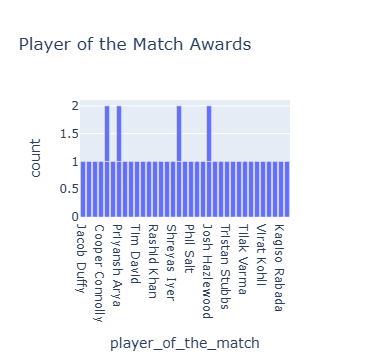

In [180]:
fig = px.bar(df, x="player_of_the_match", title="Player of the Match Awards")
fig.show()


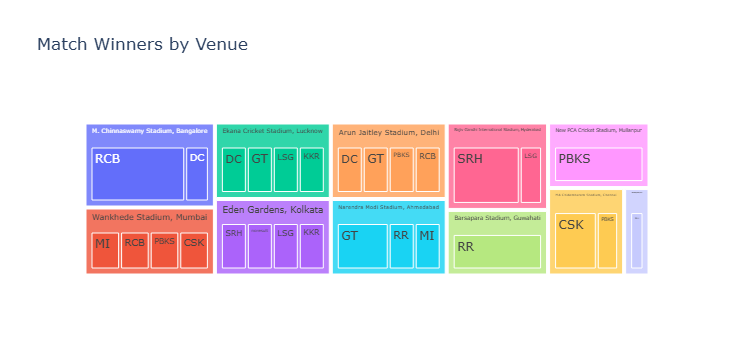

In [181]:
fig = px.treemap(df, path=["venue","match_winner"],title="Match Winners by Venue")
fig.show()


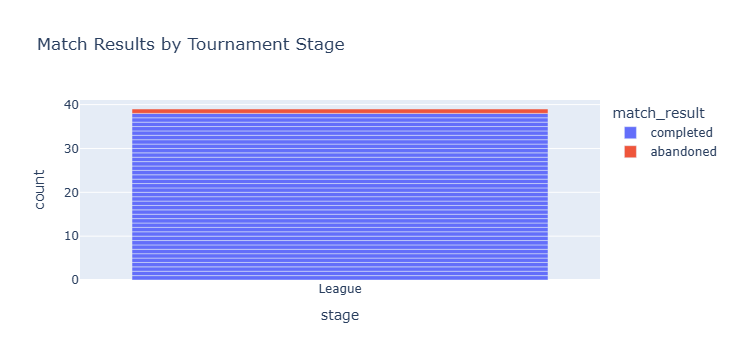

In [182]:
fig = px.bar(df, x="stage", color="match_result",
             title="Match Results by Tournament Stage")
fig.show()


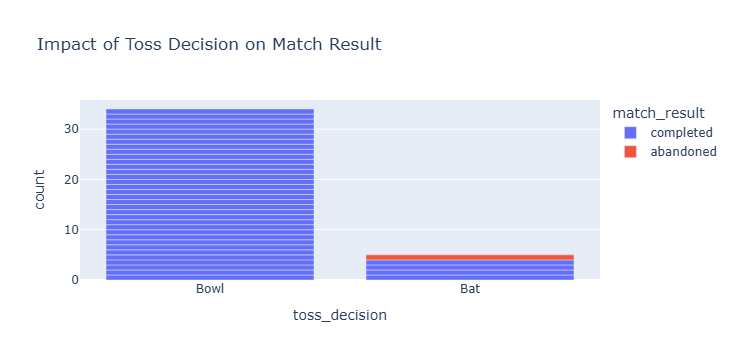

In [183]:
# Toss Decision vs Match Result
fig = px.bar(df, x="toss_decision", color="match_result",
              title="Impact of Toss Decision on Match Result")
fig.show()

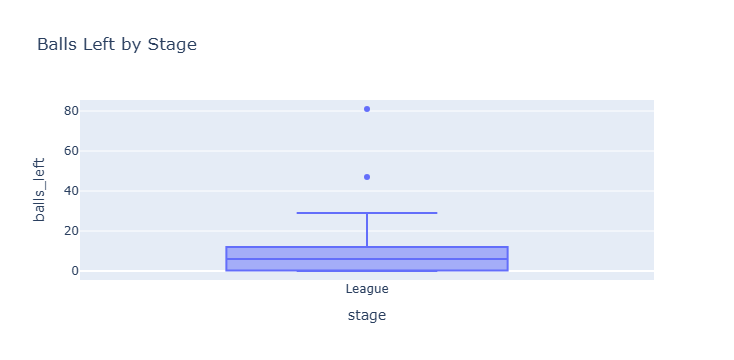

In [184]:
fig = px.box(df, x="stage", y="balls_left",
               title="Balls Left by Stage")
fig.show()


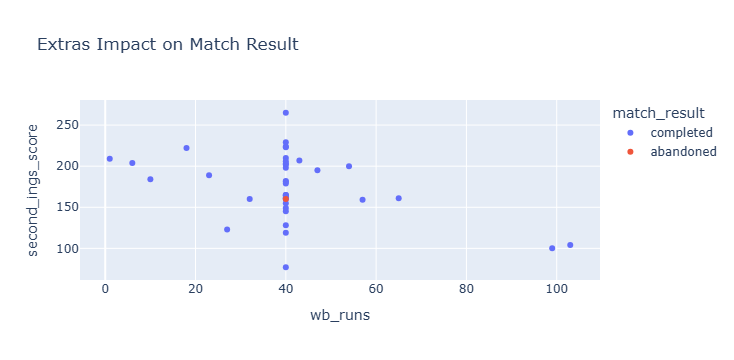

In [185]:
fig = px.scatter(df, x="wb_runs", y="second_ings_score",
                   color="match_result", title="Extras Impact on Match Result")
fig.show()

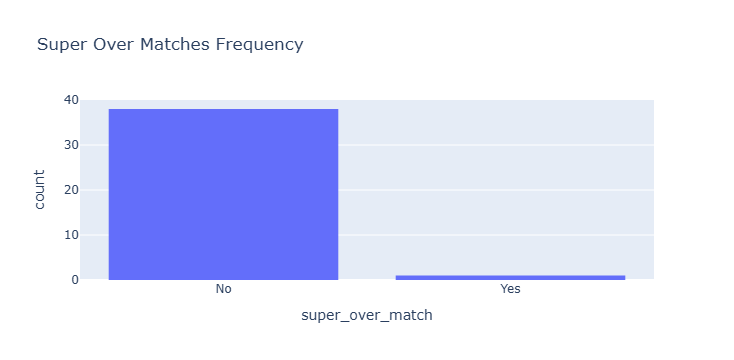

In [186]:
fig18 = px.histogram(df, x="super_over_match",
                     title="Super Over Matches Frequency")
fig18.show()

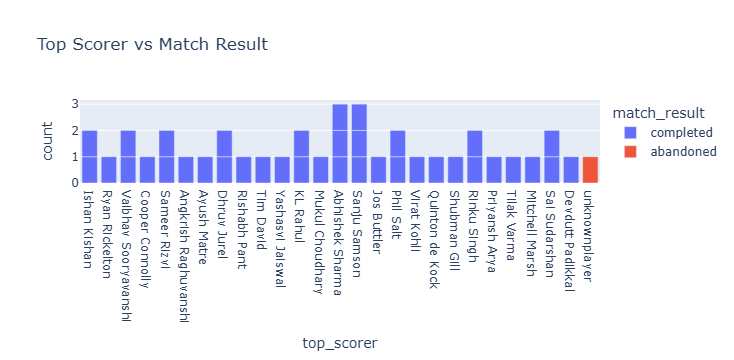

In [187]:
#  Top Scorer vs Match Result
fig= px.bar(df, x="top_scorer", color="match_result",
               title="Top Scorer vs Match Result")
fig.show()

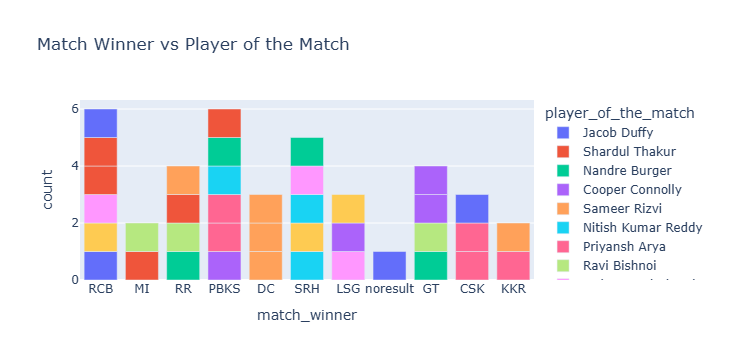

In [188]:
#  Match Winner vs Player of the Match
fig = px.bar(df, x="match_winner", color="player_of_the_match",
               title="Match Winner vs Player of the Match")
fig.show()

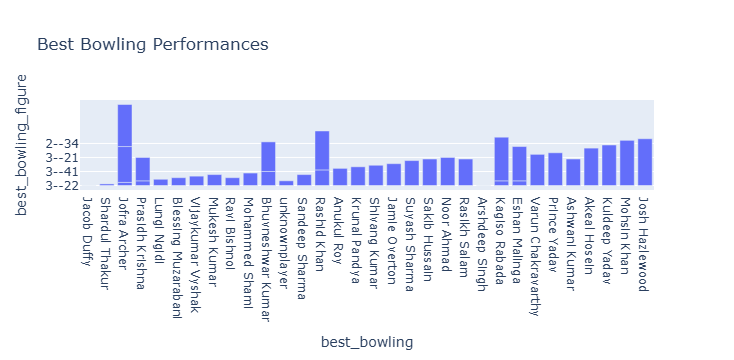

In [189]:
fig = px.bar(df, x="best_bowling", y="best_bowling_figure",
               title="Best Bowling Performances")
fig.show()

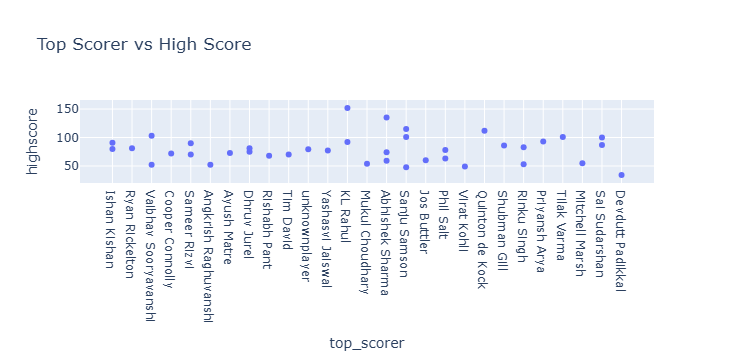

In [190]:
#  Top Scorer vs High Score
fig = px.scatter(df, x="top_scorer", y="highscore",
                   title="Top Scorer vs High Score")
fig.show()

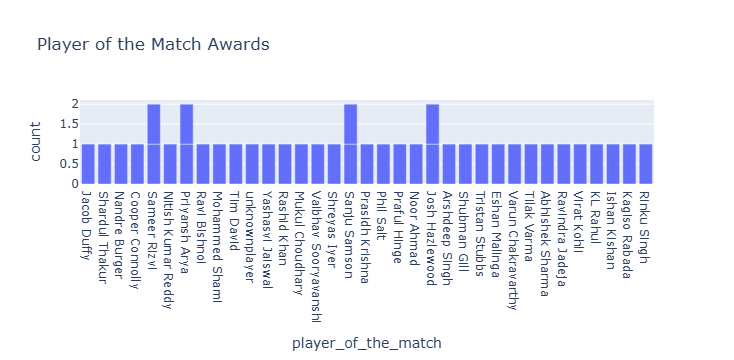

In [191]:
#  Player of the Match Frequency
fig = px.bar(df, x="player_of_the_match",
               title="Player of the Match Awards")
fig.show()

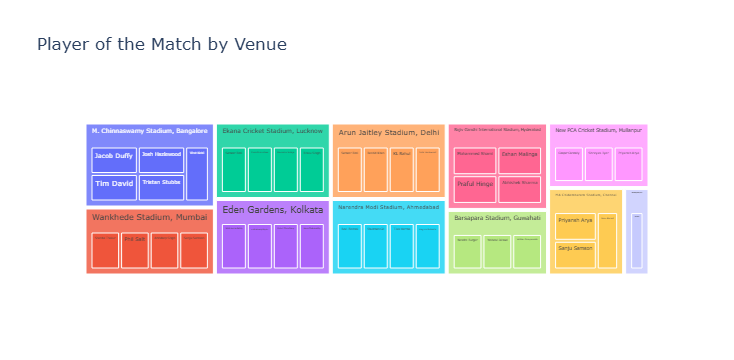

In [192]:
#  Venue vs Player of the Match
fig = px.treemap(df, path=["venue","player_of_the_match"],
                   title="Player of the Match by Venue")
fig.show()


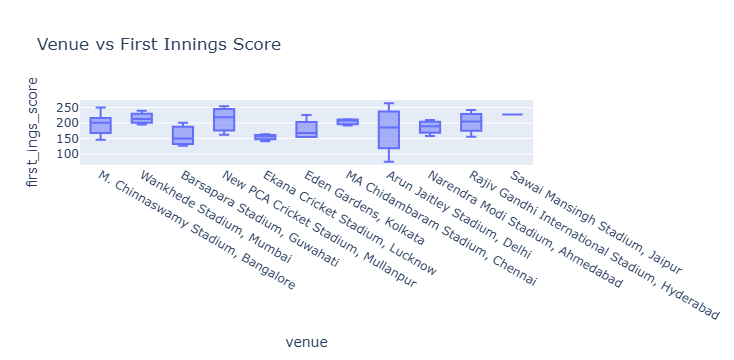

In [193]:
#  Venue vs First Innings Score
fig = px.box(df, x="venue", y="first_ings_score",
               title="Venue vs First Innings Score")
fig.show()

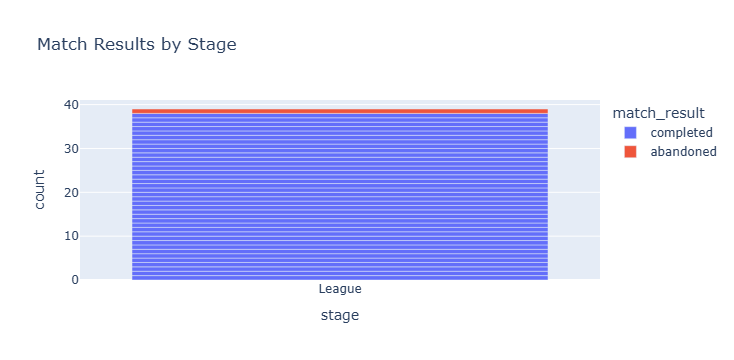

In [194]:
#  Stage vs Match Result
fig = px.bar(df, x="stage", color="match_result",
               title="Match Results by Stage")
fig.show()

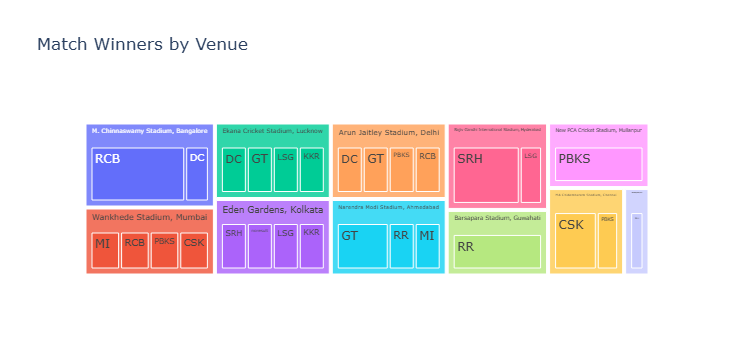

In [195]:
#  Venue vs Match Winner
fig = px.treemap(df, path=["venue","match_winner"],
                  title="Match Winners by Venue")
fig.show()

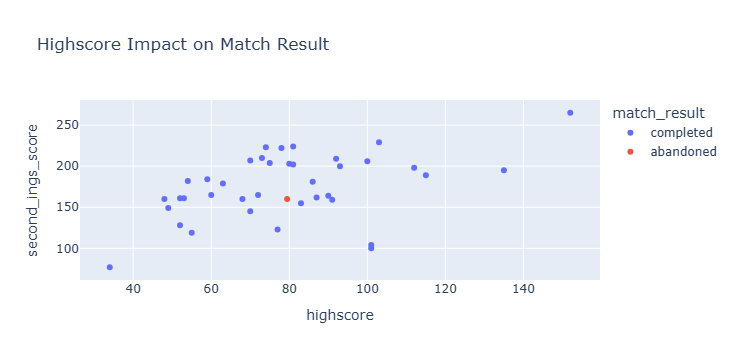

In [196]:
#  Highscore vs Match Result
fig = px.scatter(df, x="highscore", y="second_ings_score",
                  color="match_result", title="Highscore Impact on Match Result")
fig.show()


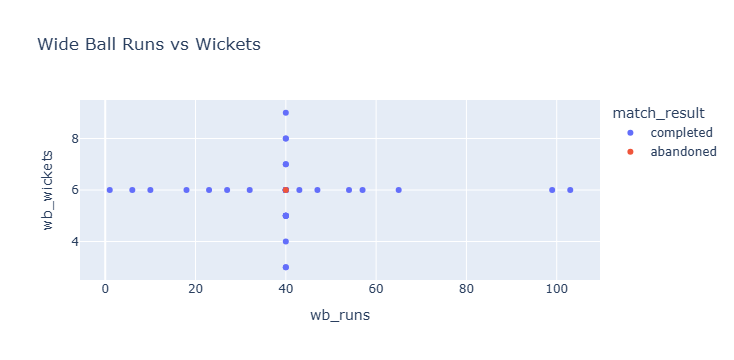

In [197]:
#  Wide Ball Runs vs Wickets
fig = px.scatter(df, x="wb_runs", y="wb_wickets", color="match_result",
                  title="Wide Ball Runs vs Wickets")
fig.show()

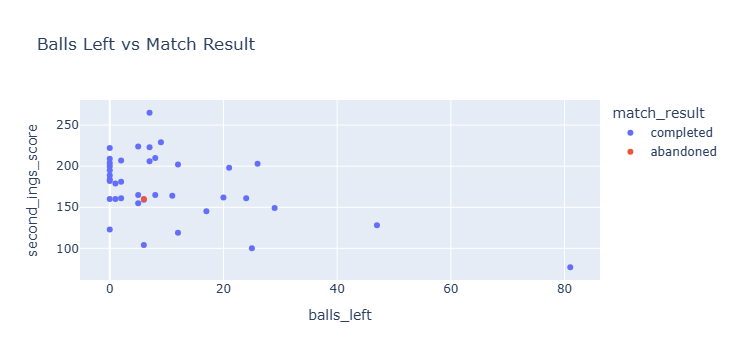

In [198]:
#  Balls Left vs Match Result
fig = px.scatter(df, x="balls_left", y="second_ings_score",
                  color="match_result", title="Balls Left vs Match Result")
fig.show()

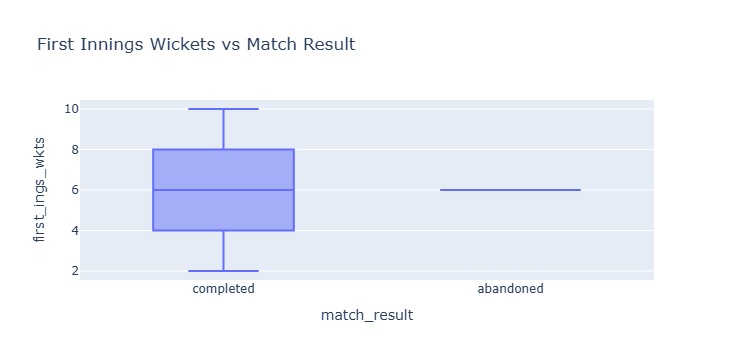

In [199]:
#  First Innings Wickets vs Match Result
fig = px.box(df, x="match_result", y="first_ings_wkts",
              title="First Innings Wickets vs Match Result")
fig.show()

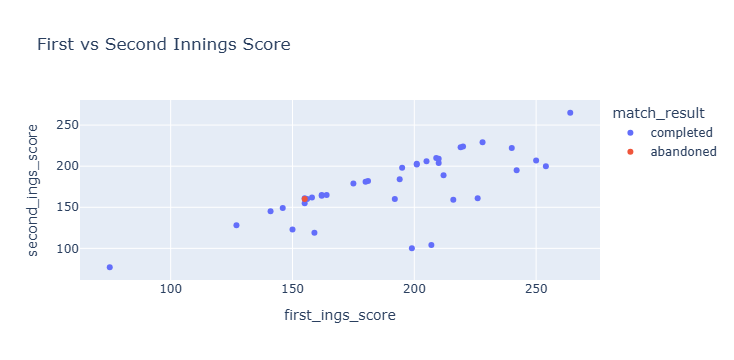

In [200]:
#  First Innings vs Second Innings Score
fig = px.scatter(df, x="first_ings_score", y="second_ings_score",
                  color="match_result", title="First vs Second Innings Score")
fig.show()


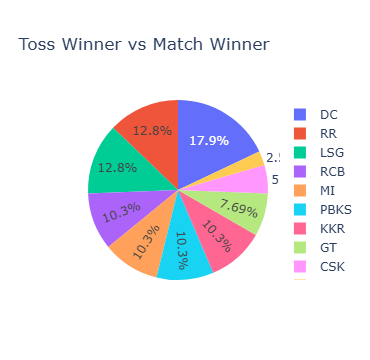

In [201]:
#  Toss Winner vs Match Winner
fig = px.pie(df, names="toss_winner", title="Toss Winner vs Match Winner")
fig.show()

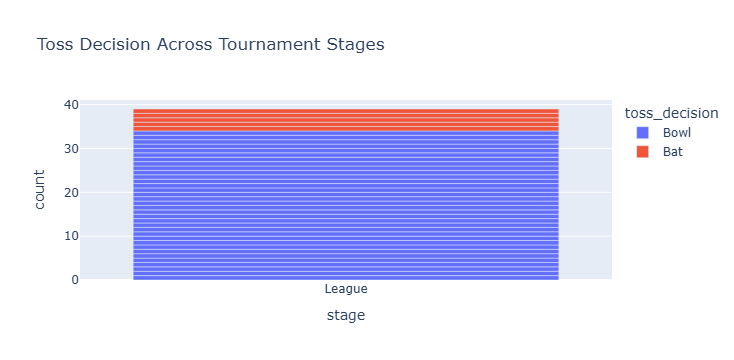

In [202]:
#  Toss Decision vs Stage
fig = px.bar(df, x="stage", color="toss_decision",
              title="Toss Decision Across Tournament Stages")
fig.show()